# Pairs-Trade Research — MTX vs other TAIFEX index futures

Explore cross-asset relationships among TAIFEX index futures. Goal: find pairs
where price ratios / spreads mean-revert reliably enough to build a market-neutral
strategy.

**In-sample window:** 2010-01-01 → 2024-12-31  (15 years).
Data after 2025-01-01 is held out as the **out-of-sample** test set — DON'T
touch it during signal construction.

Steps in this notebook:
1. Load MTX as the base asset.
2. Pull in several other TAIFEX index futures (TX, TE, TF, GDF, …).
3. Build a multi-asset feature table (close, returns, vol, OI).
4. Compute pairwise correlations and visualize normalised cumulative returns
   to eyeball candidate pairs.

(Pair-selection statistics — cointegration tests, ADF on the spread, half-life
estimates — are added in later sections.)

In [1]:
# ── Setup: imports + matplotlib CJK font ─────────────────────────────────
import importlib, sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = [
    "Hiragino Sans GB", "Heiti TC", "Songti SC",
    "PingFang HK", "Arial Unicode MS", "DejaVu Sans",
]

import cta
# Force a fresh reload of the cta submodules so notebook iterations pick up
# any source edits without restarting the kernel.
for _mod in ("cta.asset", "cta.operators", "cta.simulate",
             "cta.simulate_dollars", "cta.session_strategies",
             "cta.decomposition"):
    if _mod in sys.modules:
        importlib.reload(sys.modules[_mod])
importlib.reload(cta)

print(f"cta loaded from: {cta.__file__}")

cta loaded from: /Users/hsureggie/coding/Research/mtx/cta/__init__.py


## Date range — train / out-of-sample split

Set the **global** date range once so every `cta.Simulate` / `cta.SimulateAll` /
`cta.simulate_by_dollars` call done in this notebook is automatically clipped
to the in-sample window.

When you're ready to test, change the range to e.g. `start_date='2025-01-01',
end_date=None` and re-run the relevant cells.

In [2]:
IN_SAMPLE_START = "2010-01-01"
IN_SAMPLE_END   = "2024-12-31"

cta.set_date_range(start_date=IN_SAMPLE_START, end_date=IN_SAMPLE_END)
print(f"Global eval window: {cta.get_date_range()}")

Global eval window: (Timestamp('2010-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))


## What's available

List every TAIFEX index-future code we have a CSV for. Then load MTX as the
base and pick a handful of plausible pair candidates.

In [3]:
available = cta.available_assets()
print(f"{len(available)} contract codes with history_data CSVs:")
for i in range(0, len(available), 8):
    print("   " + "  ".join(f"{c:<5}" for c in available[i:i+8]))

30 contract codes with history_data CSVs:
   BRF    BTF    E4F    F1F    G2F    GDF    GTF    M1F  
   MTX    RHF    RTF    SHF    SOF    SPF    SXF    TE   
   TF     TGF    TJF    TMF    TX     UDF    UNF    XAF  
   XBF    XEF    XIF    XJF    ZEF    ZFF  


## Load MTX + candidate pair futures

Loading the full history per asset (not yet sliced to the in-sample window —
we keep full history so rolling features have a real warmup).

Candidate group:
- **TX**: 大型台指期 — same underlying as MTX (TAIEX), 200 NTD/pt vs MTX's 50.
  Should be ~perfectly cointegrated (test will confirm).
- **TE**: 台指電子期 — TAIEX Electronics sector (huge TSMC weight, but not 100%).
- **TF**: 台指金融期 — TAIEX Financials sector.
- **TGF**: 櫃買期 — TPEx (OTC) index, smaller-cap proxy.
- **XIF**: 非金電期 — TAIEX ex-Financials-and-Electronics.
- **GDF**: 黃金期 — USD-denominated gold; expect low correlation, useful as
  a cross-asset benchmark.

Each is loaded as its own `BaseAsset` (full history retained — we slice for
display in the next cell).

In [4]:
CANDIDATES = ["MTX", "TX", "TE", "TF", "TGF", "XIF", "GDF"]

assets = {}
for code in CANDIDATES:
    try:
        assets[code] = cta.load_asset(code, "1d", contract="front")
    except FileNotFoundError as e:
        print(f"  skip {code}: {e}")

# Restore MTX as the active asset for any subsequent operator calls
cta.load_asset("MTX", "1d", contract="front")

# Quick per-asset summary
rows = []
for code, a in assets.items():
    rows.append({
        "code":       code,
        "rows":       len(a),
        "start":      a.index[0].date(),
        "end":        a.index[-1].date(),
        "last_close": float(a.close.iloc[-1]),
        "has_night":  bool("night_open" in a.columns and a["night_open"].notna().any()),
    })
pd.DataFrame(rows).set_index("code")

,rows,start,end,last_close,has_night
code,,,,,
MTX,6181,2001-04-09,2026-05-15,41001.0,True
TX,6904,1998-07-21,2026-05-15,41012.0,True
TE,6635,1999-07-21,2026-05-15,2657.7,True
TF,6635,1999-07-21,2026-05-15,2519.0,True
TGF,4490,2008-01-28,2026-05-15,17565.5,True
XIF,4568,2007-10-08,2026-05-15,13932.0,False
GDF,2947,2006-03-27,2026-05-15,4585.4,True


## Feature table — close, returns, log-returns, volume, OI

Build a multi-asset DataFrame aligned to the common trading calendar within
the in-sample window. We use the **roll-adjusted `asset.returns`** so the
calendar-spread artifact doesn't pollute correlations.

In [5]:
def _restrict(s):
    """Trim a series to the in-sample window."""
    return s.loc[IN_SAMPLE_START:IN_SAMPLE_END]

close  = pd.DataFrame({c: _restrict(a.close)            for c, a in assets.items()})
ret    = pd.DataFrame({c: _restrict(a.returns)          for c, a in assets.items()})  # roll-adjusted
volume = pd.DataFrame({c: _restrict(a.volume)           for c, a in assets.items()})
oi     = pd.DataFrame({c: _restrict(a.oi)               for c, a in assets.items()})
logret = np.log1p(ret)

print(f"Aligned in-sample window: {ret.index[0].date()} → {ret.index[-1].date()}  "
      f"({len(ret):,} bars)")
print()
print("Coverage per asset (non-NaN return days):")
print(ret.notna().sum().to_frame("rows").T.to_string())
print()
print("Tail of `close`:")
close.tail(3)

Aligned in-sample window: 2010-01-04 → 2024-12-31  (3,681 bars)

Coverage per asset (non-NaN return days):
       MTX    TX    TE    TF   TGF   XIF   GDF
rows  3681  3681  3681  3681  3680  3681  1971

Tail of `close`:


,MTX,TX,TE,TF,TGF,XIF,GDF
date,,,,,,,
2024-12-27,23376.0,23372.0,1303.1,2130.2,10446.5,14313.0,2627.9
2024-12-30,23170.0,23177.0,1290.6,2121.8,10474.0,14219.0,2644.8
2024-12-31,23043.0,23041.0,1282.1,2105.4,10439.0,14175.0,2624.3


## Correlation matrix of daily returns

High correlation → strong common factor (good base for cointegration / pair
spread). Low correlation → cross-asset diversifier (different question).

For pairs trade we ideally want **high contemporaneous return correlation
PLUS a stationary price spread**. The latter we'll check next; the former
shows here.

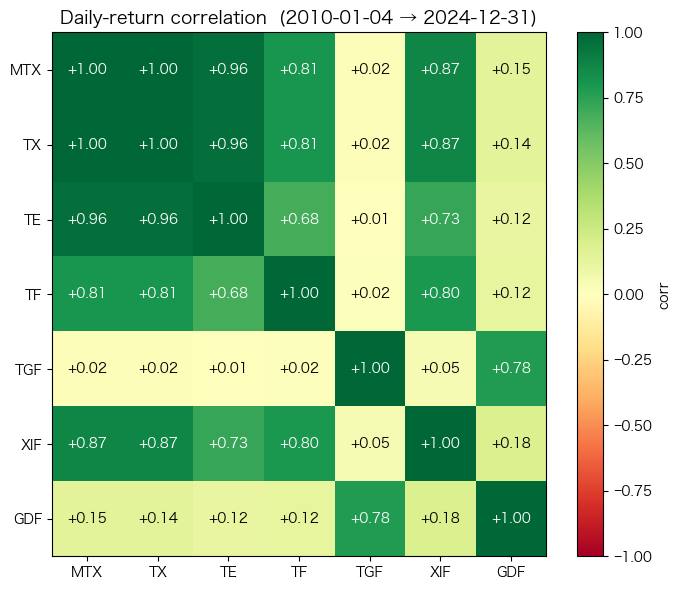

In [6]:
corr = ret.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.iat[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "black", fontsize=10)
ax.set_title(f"Daily-return correlation  ({ret.index[0].date()} → {ret.index[-1].date()})",
             fontsize=13)
plt.colorbar(im, ax=ax, label="corr")
plt.tight_layout()
plt.show()

## Normalised cumulative returns — eyeball the relative drift

Re-base each series to 1.0 at the first in-sample day so we can see relative
performance on one chart. Pairs that track each other tightly until diverging
into a recognisable spread are good pair-trade candidates.

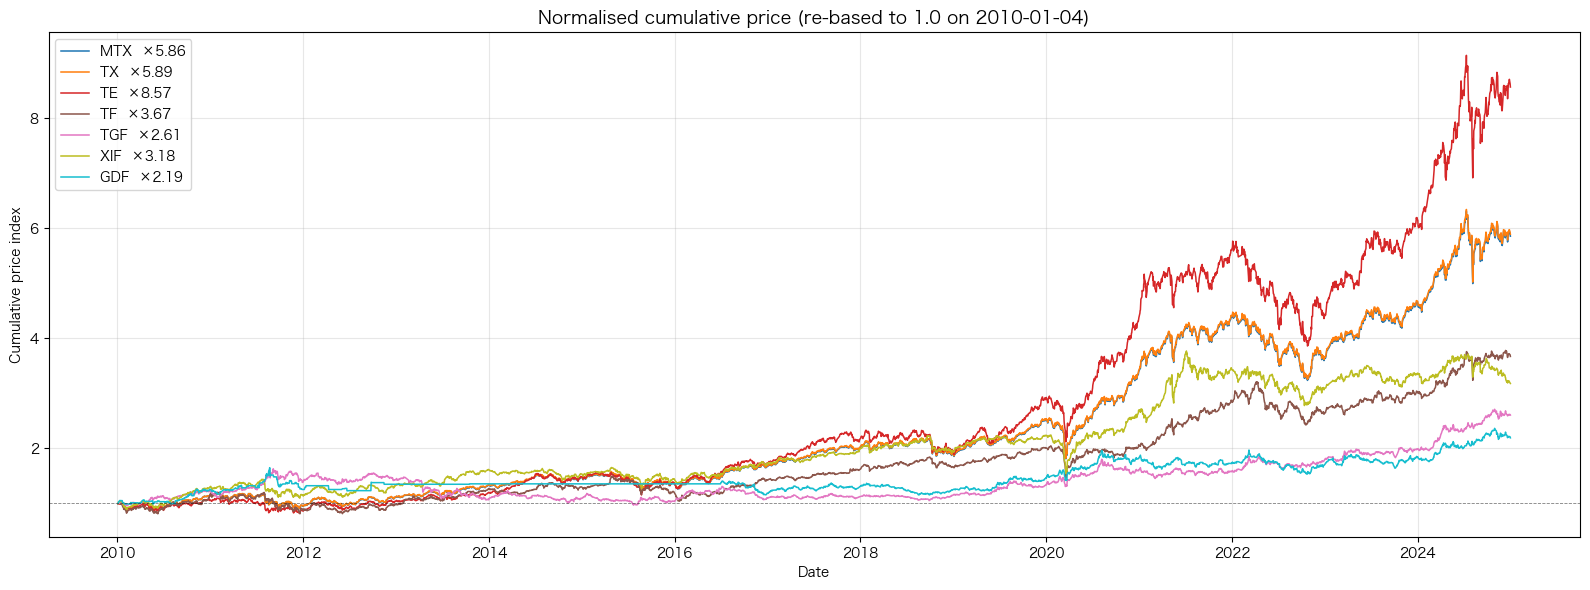

In [7]:
cum = (1 + ret.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(16, 6))
colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(cum.columns)))
for c, color in zip(cum.columns, colors):
    end = cum[c].iloc[-1]
    ax.plot(cum.index, cum[c].values, color=color, linewidth=1.1,
            label=f"{c}  ×{end:.2f}")
ax.axhline(1.0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_title(f"Normalised cumulative price (re-based to 1.0 on {cum.index[0].date()})",
             fontsize=13)
ax.set_ylabel("Cumulative price index")
ax.set_xlabel("Date")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pair-test toolbox

Stand-alone helpers (no external stats library needed):

- **`ols_regress(y, x)`** — fit `y = α + β·x + ε`, return coefficients and the
  spread series `ε`.
- **`adf_test(series)`** — Dickey-Fuller test for unit root (constant, no
  trend, no lag-augmentation). Returns the test stat and MacKinnon
  critical values. **Engle-Granger 5% critical for cointegration residuals
  is ≈ −3.34** (stricter than the standard ADF −2.86 because the residuals
  are estimated, not observed).
- **`half_life(spread)`** — AR(1) on the spread: `Δs = a + b·s_{t-1} + ε`,
  then `half_life = −ln(2) / ln(1 + b)`. Tells you how many bars a typical
  deviation takes to halve.
- **`rolling_zscore(series, window)`** — `(s − mean) / std` over a trailing
  window. Used to convert the spread into a tradeable signal.

In [8]:
def ols_regress(y: pd.Series, x: pd.Series) -> dict:
    """
    Fit y = alpha + beta * x + eps  by OLS on the aligned subset.
    Returns alpha, beta, fitted, spread (=residuals), R^2, and the aligned index.
    """
    df = pd.concat([y, x], axis=1).dropna()
    if len(df) < 30:
        return {"alpha": np.nan, "beta": np.nan, "spread": pd.Series(dtype=float),
                "fitted": pd.Series(dtype=float), "r2": np.nan, "n": len(df)}
    yv, xv = df.iloc[:, 0].values, df.iloc[:, 1].values
    X = np.column_stack([np.ones(len(xv)), xv])
    coefs, *_ = np.linalg.lstsq(X, yv, rcond=None)
    alpha, beta = coefs
    fitted = alpha + beta * xv
    spread = yv - fitted
    ss_res = (spread ** 2).sum()
    ss_tot = ((yv - yv.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {
        "alpha":  float(alpha),
        "beta":   float(beta),
        "spread": pd.Series(spread, index=df.index, name="spread"),
        "fitted": pd.Series(fitted, index=df.index, name="fitted"),
        "r2":     float(r2),
        "n":      len(df),
    }


def adf_test(series: pd.Series) -> dict:
    """
    Augmented Dickey-Fuller test (lag 0, constant, no trend) — minimal version.
    Δy_t = α + β·y_{t-1} + ε  ;  H0: β = 0 (unit root) ;  H1: β < 0 (stationary).
    """
    s = pd.Series(series).dropna()
    if len(s) < 30:
        return {"t_stat": np.nan, "crit_5pct": -2.86, "crit_1pct": -3.43, "n": len(s)}
    y    = s.values
    dy   = np.diff(y)
    ylag = y[:-1]
    X    = np.column_stack([np.ones(len(ylag)), ylag])
    coefs, *_ = np.linalg.lstsq(X, dy, rcond=None)
    alpha, beta = coefs
    resid = dy - X @ coefs
    n     = len(dy)
    sigma2 = (resid ** 2).sum() / (n - 2)
    var_x  = ((ylag - ylag.mean()) ** 2).sum()
    se_beta = np.sqrt(sigma2 / var_x) if var_x > 0 else np.nan
    t_stat = beta / se_beta if se_beta and se_beta > 0 else np.nan
    return {
        "t_stat":     float(t_stat),
        "crit_5pct":  -2.86,        # ADF on observed series
        "crit_1pct":  -3.43,
        # Engle-Granger critical for residuals from a 2-var cointegration regression:
        "eg_5pct":    -3.34,
        "eg_1pct":    -3.90,
        "n":          int(n),
    }


def half_life(spread: pd.Series) -> float:
    """
    Half-life of mean reversion via AR(1):  Δs_t = a + b·s_{t-1} + ε
    Returns -ln(2)/ln(1+b) in bars. Returns ∞ if non-mean-reverting (b ≥ 0).
    """
    s = pd.Series(spread).dropna()
    if len(s) < 30:
        return np.nan
    s_lag  = s.shift(1).dropna()
    s_diff = s.diff().dropna()
    idx    = s_lag.index.intersection(s_diff.index)
    X = np.column_stack([np.ones(len(idx)), s_lag.loc[idx].values])
    coefs, *_ = np.linalg.lstsq(X, s_diff.loc[idx].values, rcond=None)
    _a, b = coefs
    if b >= 0:
        return float("inf")
    return float(-np.log(2) / np.log(1 + b))


def rolling_zscore(s: pd.Series, window: int = 60, min_periods: int = 20) -> pd.Series:
    """Rolling z-score with no look-ahead."""
    mu  = s.rolling(window, min_periods=min_periods).mean()
    sig = s.rolling(window, min_periods=min_periods).std(ddof=1).replace(0, np.nan)
    return ((s - mu) / sig).rename("zscore")

## Pair-level cointegration table

Run the Engle-Granger test for every candidate against MTX, on both raw and
log prices. Sort by ADF t-stat — more negative = stronger evidence of a
stationary spread.

We test in **log space** because:
- price levels differ wildly (TE ~600, TX ~18000); log makes them dimensionless
- a stable β in log space means a stable *price ratio*, which is the natural
  hedge ratio for index futures with different point values
- residuals in log space approximate percentage spread, easier to interpret

In [9]:
log_close = np.log(close)

rows = []
for code in close.columns:
    if code == "MTX":
        continue
    # Cointegration regression: log(MTX) = alpha + beta * log(other) + spread
    reg = ols_regress(log_close["MTX"], log_close[code])
    if not len(reg["spread"]):
        continue
    adf = adf_test(reg["spread"])
    hl  = half_life(reg["spread"])
    rows.append({
        "pair":        f"MTX ~ {code}",
        "n":           reg["n"],
        "beta":        reg["beta"],
        "R²":          reg["r2"],
        "ADF t-stat":  adf["t_stat"],
        "EG 5% crit":  adf["eg_5pct"],
        "cointegrated@5%": "YES" if adf["t_stat"] < adf["eg_5pct"] else "no",
        "half-life (d)":   hl,
    })

table = (pd.DataFrame(rows)
           .sort_values("ADF t-stat")          # most negative first = strongest
           .reset_index(drop=True))
table

,pair,n,beta,R²,ADF t-stat,EG 5% crit,cointegrated@5%,half-life (d)
0,MTX ~ TX,3681,0.999958,1.000000,-60.530673,-3.34,YES,0.110408
1,MTX ~ TE,3681,0.748977,0.992377,-3.744181,-3.34,YES,99.930832
2,MTX ~ GDF,1989,1.161916,0.714975,-2.858903,-3.34,no,84.030054
3,MTX ~ TF,3681,1.209910,0.928372,-2.774062,-3.34,no,164.929429
4,MTX ~ TGF,3680,1.146157,0.550704,-2.135879,-3.34,no,279.025528
5,MTX ~ XIF,3681,1.854750,0.859734,-1.590644,-3.34,no,287.628785


## Deep dive on one pair — spread, z-score, trade signal

Pick a pair from the table above and inspect it:

1. **Top:** the two prices side-by-side (twin y-axes since scales differ).
2. **Middle:** the spread (= residual from the OLS hedge) over time,
   plus rolling mean / ±2σ bands.
3. **Bottom:** the rolling z-score with horizontal bands at ±1 and ±2.
   The standard pairs-trade rules:
   - z > +2 → spread is "too high" → **short** the spread
     (short the dependent, long β × independent)
   - z < −2 → spread is "too low" → **long** the spread
   - exit on |z| < 0.5

Edit `PAIR_TO_INSPECT` to change which pair gets the deep-dive treatment.

/var/folders/ph/6k474nt57bsbh53k8tc674dr0000gn/T/ipykernel_12244/3570849251.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


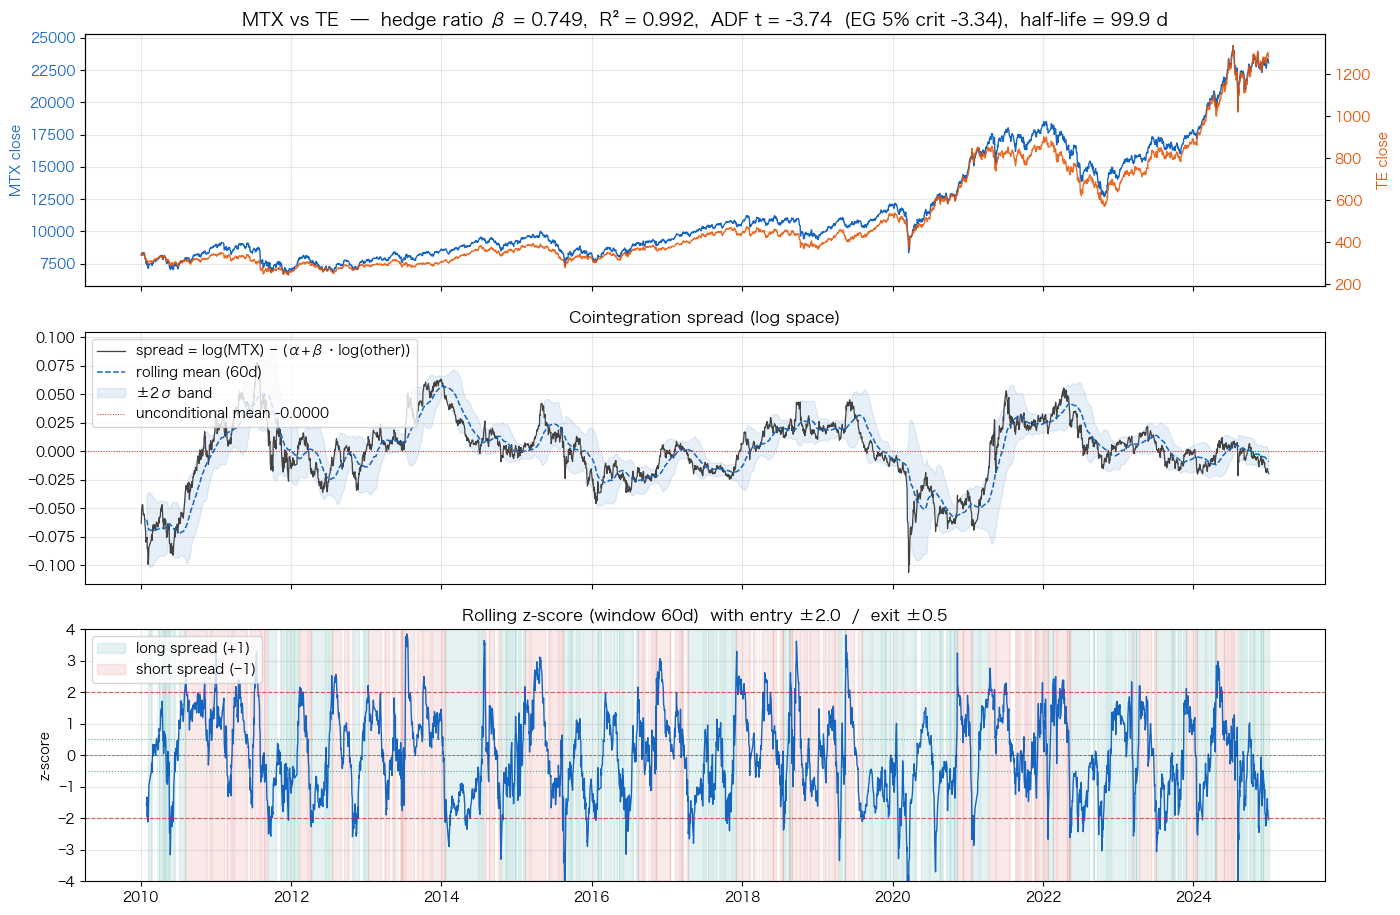

Signal coverage:  long 1453d  short 1366d  flat 862d  (77% of bars holding a position)


In [10]:
PAIR_TO_INSPECT = "TE"                # pick from the cointegration table
Z_WINDOW        = 60                  # bars for the rolling z-score
ENTRY_Z         = 2.0
EXIT_Z          = 0.5

y_log = log_close["MTX"]
x_log = log_close[PAIR_TO_INSPECT]
reg   = ols_regress(y_log, x_log)
spread = reg["spread"]
z      = rolling_zscore(spread, window=Z_WINDOW)
hl     = half_life(spread)
adf    = adf_test(spread)

# Trade signal (mean-reversion logic): -1 when spread is "high", +1 when "low"
sig_pos = pd.Series(0.0, index=z.index)
sig_pos[z >  ENTRY_Z] = -1
sig_pos[z < -ENTRY_Z] =  1
# Hold position until z crosses the EXIT band: forward-fill, clear when |z| < EXIT_Z
sig_pos = sig_pos.replace(0, np.nan).ffill().fillna(0)
sig_pos[z.abs() < EXIT_Z] = 0

# ─── plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 2], "hspace": 0.18})

# (0) Prices on twin axes
ax = axes[0]
y_price = close["MTX"].loc[spread.index]
x_price = close[PAIR_TO_INSPECT].loc[spread.index]
ax.plot(y_price.index, y_price.values, color="#1565c0", linewidth=1.0, label="MTX (left)")
ax.set_ylabel("MTX close", color="#1565c0")
ax.tick_params(axis="y", labelcolor="#1565c0")
ax2 = ax.twinx()
ax2.plot(x_price.index, x_price.values, color="#e65100", linewidth=1.0,
         alpha=0.85, label=f"{PAIR_TO_INSPECT} (right)")
ax2.set_ylabel(f"{PAIR_TO_INSPECT} close", color="#e65100")
ax2.tick_params(axis="y", labelcolor="#e65100")
ax.set_title(f"MTX vs {PAIR_TO_INSPECT}  —  hedge ratio β = {reg['beta']:.3f},  "
             f"R² = {reg['r2']:.3f},  ADF t = {adf['t_stat']:+.2f}  "
             f"(EG 5% crit {adf['eg_5pct']:.2f}),  half-life = {hl:.1f} d",
             fontsize=13)
ax.grid(True, alpha=0.3)

# (1) Spread + rolling mean / ±2σ bands
ax = axes[1]
mu  = spread.rolling(Z_WINDOW, min_periods=20).mean()
sig = spread.rolling(Z_WINDOW, min_periods=20).std(ddof=1)
ax.plot(spread.index, spread.values, color="#424242", linewidth=0.9, label="spread = log(MTX) − (α+β·log(other))")
ax.plot(mu.index, mu.values, color="#1565c0", linewidth=1.1, linestyle="--", label=f"rolling mean ({Z_WINDOW}d)")
ax.fill_between(mu.index, (mu - 2 * sig).values, (mu + 2 * sig).values,
                color="#1565c0", alpha=0.10, label="±2σ band")
ax.axhline(spread.mean(), color="#c62828", linewidth=0.7, linestyle=":", label=f"unconditional mean {spread.mean():+.4f}")
ax.set_title("Cointegration spread (log space)", fontsize=12)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)

# (2) z-score with entry / exit bands + position colour fill
ax = axes[2]
ax.plot(z.index, z.values, color="#1565c0", linewidth=1.0)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
for lvl, ls in [(+ENTRY_Z, "--"), (-ENTRY_Z, "--"), (+EXIT_Z, ":"), (-EXIT_Z, ":")]:
    ax.axhline(lvl, color="#c62828" if abs(lvl) >= ENTRY_Z else "#00897b",
               linewidth=0.8, linestyle=ls, alpha=0.7)
ax.fill_between(z.index, -4, 4, where=(sig_pos == +1), color="#00897b", alpha=0.10,
                label="long spread (+1)")
ax.fill_between(z.index, -4, 4, where=(sig_pos == -1), color="#c62828", alpha=0.10,
                label="short spread (−1)")
ax.set_ylim(-4, 4)
ax.set_title(f"Rolling z-score (window {Z_WINDOW}d)  with entry ±{ENTRY_Z}  /  exit ±{EXIT_Z}",
             fontsize=12)
ax.set_ylabel("z-score")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Signal coverage:  long {(sig_pos == +1).sum()}d  "
      f"short {(sig_pos == -1).sum()}d  "
      f"flat {(sig_pos == 0).sum()}d  "
      f"({((sig_pos != 0).sum() / len(sig_pos) * 100):.0f}% of bars holding a position)")

## Stability check — rolling β and rolling correlation

Cointegration over the full sample is necessary but not sufficient.
A pair is only tradeable if the hedge ratio is **stable through time**.
If β drifts significantly, the constant-β spread will pick up trend instead
of mean-reverting noise.

This cell plots:
1. **Rolling β** over a 252-day window — should be roughly flat for a real pair.
2. **Rolling 60-day return correlation** — when this collapses, the pair is
   temporarily decoupled and you should avoid trading the spread.

/var/folders/ph/6k474nt57bsbh53k8tc674dr0000gn/T/ipykernel_12244/661179982.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


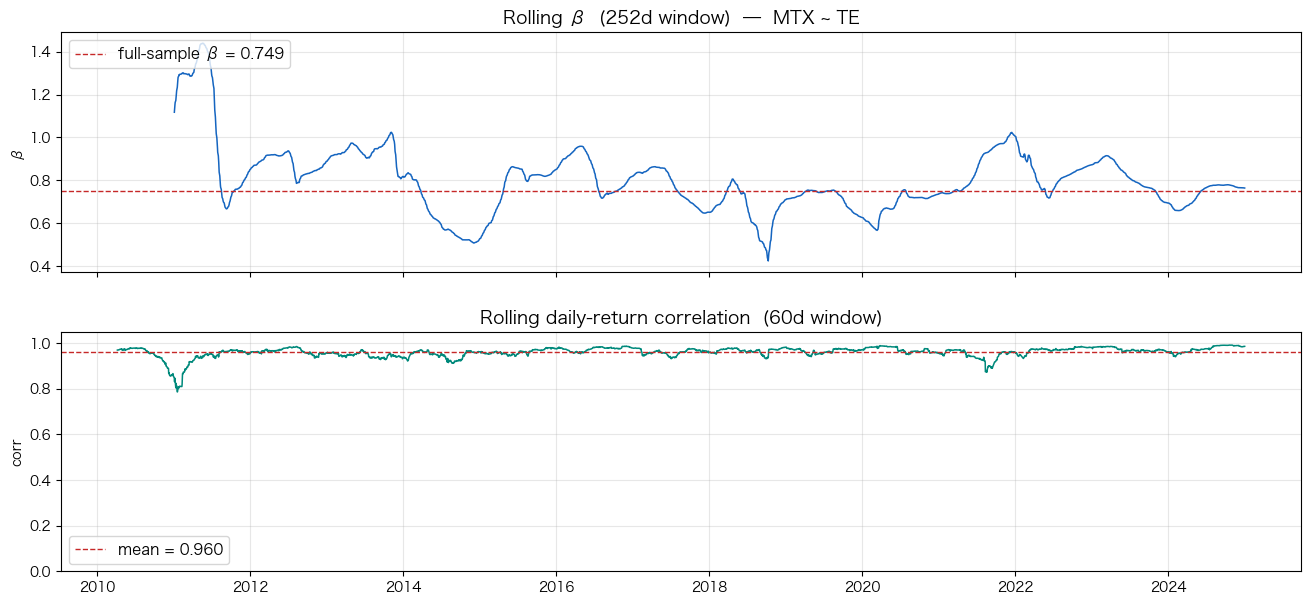

Rolling β:      mean +0.798   std 0.154   min +0.423   max +1.440
Rolling corr:   mean +0.960   min +0.786   max +0.992


In [11]:
def rolling_beta(y: pd.Series, x: pd.Series, window: int) -> pd.Series:
    """Rolling OLS slope of y on x (no intercept correction — same as cov/var)."""
    df = pd.concat([y, x], axis=1).dropna()
    yv, xv = df.iloc[:, 0], df.iloc[:, 1]
    cov  = yv.rolling(window).cov(xv)
    varx = xv.rolling(window).var()
    return (cov / varx).rename(f"beta({y.name}~{x.name},{window}d)")


BETA_WINDOW = 252
CORR_WINDOW = 60

rb = rolling_beta(log_close["MTX"], log_close[PAIR_TO_INSPECT], BETA_WINDOW)
rc = ret["MTX"].rolling(CORR_WINDOW).corr(ret[PAIR_TO_INSPECT])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={"hspace": 0.25})

axes[0].plot(rb.index, rb.values, color="#1565c0", linewidth=1.1)
axes[0].axhline(reg["beta"], color="#c62828", linewidth=1.0, linestyle="--",
                label=f"full-sample β = {reg['beta']:.3f}")
axes[0].set_title(f"Rolling β  ({BETA_WINDOW}d window)  —  MTX ~ {PAIR_TO_INSPECT}",
                  fontsize=13)
axes[0].set_ylabel("β")
axes[0].legend(fontsize=11, loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(rc.index, rc.values, color="#00897b", linewidth=1.1)
axes[1].axhline(rc.mean(), color="#c62828", linewidth=1.0, linestyle="--",
                label=f"mean = {rc.mean():.3f}")
axes[1].axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
axes[1].set_title(f"Rolling daily-return correlation  ({CORR_WINDOW}d window)",
                  fontsize=13)
axes[1].set_ylabel("corr")
axes[1].set_ylim(min(0, rc.min() - 0.05), 1.05)
axes[1].legend(fontsize=11, loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rolling β:      mean {rb.mean():+.3f}   std {rb.std():.3f}   "
      f"min {rb.min():+.3f}   max {rb.max():+.3f}")
print(f"Rolling corr:   mean {rc.mean():+.3f}   min {rc.min():+.3f}   max {rc.max():+.3f}")

## Vanilla pairs-trading strategy

Two flavours of mean-reversion signal on the MTX–vs–other spread. **Both
output an MTX position signal**, so we can pipe them straight into
`cta.SimulateAll`. The implicit "other" leg is what would short/long the
hedge if you traded it as a true pair — we're only measuring the MTX side
of the trade here.

**Version A — Cumulative-return spread**

```
spread_t        = cum_ret(MTX, N)_t  −  cum_ret(other, N)_t
z_t             = (spread_t − μ) / σ          (rolling 252-day stats)
position_MTX_t  = −1   if z_t >= +threshold      (MTX outperformed → short)
                  +1   if z_t <= −threshold      (MTX underperformed → long)
                   0   otherwise
```

**Version B — Log-price-difference spread (cointegration style)**

```
β_t      = rolling 252-day OLS slope of log(MTX) on log(other)
spread_t = log(MTX_t)  −  β_t · log(other_t)
z_t      = (spread_t − μ) / σ
(same signal logic)
```

`hold_until_revert=True` keeps the position open after entry until z
crosses zero (the standard pair-trade rule). `hold_until_revert=False` is
the simpler "bang-bang" version that only holds while |z| ≥ threshold.

In [12]:
def _z_to_position(z: pd.Series, threshold: float = 1.5,
                    hold_until_revert: bool = True) -> pd.Series:
    """
    Convert a spread z-score into an MTX position signal.

    bang-bang  : -1 if z >=  threshold ;  +1 if z <= -threshold ;  0 otherwise.
    hold-state : enter at ±threshold, exit when z crosses 0.
    """
    if not hold_until_revert:
        sig = pd.Series(0.0, index=z.index)
        sig[z >=  threshold] = -1.0
        sig[z <= -threshold] =  1.0
        return sig

    vals = z.values
    out  = np.zeros(len(vals))
    cur  = 0
    for i, zi in enumerate(vals):
        if np.isnan(zi):
            out[i] = cur
            continue
        if cur == 0:
            if   zi >=  threshold: cur = -1
            elif zi <= -threshold: cur =  1
        elif cur > 0 and zi >= 0:   cur = 0      # long → exit on cross up
        elif cur < 0 and zi <= 0:   cur = 0      # short → exit on cross down
        out[i] = cur
    return pd.Series(out, index=z.index, name="pair_sig")


def cum_ret_spread_signal(
    mtx_ret: pd.Series, other_ret: pd.Series,
    lookback:   int = 20,
    std_window: int = 252,
    threshold:  float = 1.5,
    hold_until_revert: bool = True,
) -> pd.Series:
    """
    Version A: position from past-`lookback`-day cumulative-return spread.

    Both series are aligned to MTX's calendar; days where the partner did
    not trade are treated as zero return so the rolling spread stays defined.
    """
    m = mtx_ret.fillna(0)
    o = other_ret.reindex(mtx_ret.index).fillna(0)
    cum_m = m.rolling(lookback).sum()
    cum_o = o.rolling(lookback).sum()
    sp    = cum_m - cum_o
    mu    = sp.rolling(std_window).mean()
    sd    = sp.rolling(std_window).std().replace(0, np.nan)
    z     = ((sp - mu) / sd).replace([np.inf, -np.inf], np.nan)
    return _z_to_position(z, threshold=threshold, hold_until_revert=hold_until_revert)


def log_price_spread_signal(
    mtx_close: pd.Series, other_close: pd.Series,
    beta_window: int = 252,
    std_window:  int = 252,
    threshold:   float = 1.5,
    hold_until_revert: bool = True,
) -> pd.Series:
    """
    Version B: position from log-price spread `log(MTX) − β·log(other)`,
    with β estimated by rolling OLS (no look-ahead).

    Partner close is forward-filled on MTX-only trading days so the rolling
    β / spread stay defined.
    """
    lm = np.log(mtx_close)
    lo = np.log(other_close.reindex(mtx_close.index).ffill())
    cov = lm.rolling(beta_window).cov(lo)
    var = lo.rolling(beta_window).var().replace(0, np.nan)
    beta = cov / var
    sp = lm - beta * lo
    mu = sp.rolling(std_window).mean()
    sd = sp.rolling(std_window).std().replace(0, np.nan)
    z  = ((sp - mu) / sd).replace([np.inf, -np.inf], np.nan)
    return _z_to_position(z, threshold=threshold, hold_until_revert=hold_until_revert)

### A. Cumulative-return spread across multiple pairs

Run the cum-ret signal at `lookback=20`, `threshold=1.5` against four pair
partners — one from each row of the cointegration table:

| Pair | Why it's interesting |
|---|---|
| TE | Strongly cointegrated; long half-life |
| TF | High return-correlation but **not** ADF-stationary |
| GDF | Cross-asset (gold) — sanity check |
| XIF | TAIEX ex-finance/electronics, broad-equity overlap |

The MTX signal here measures the value of the *MTX leg* of the pair —
when the spread says "MTX is too high vs other", we short MTX; when "too
low", we long it.

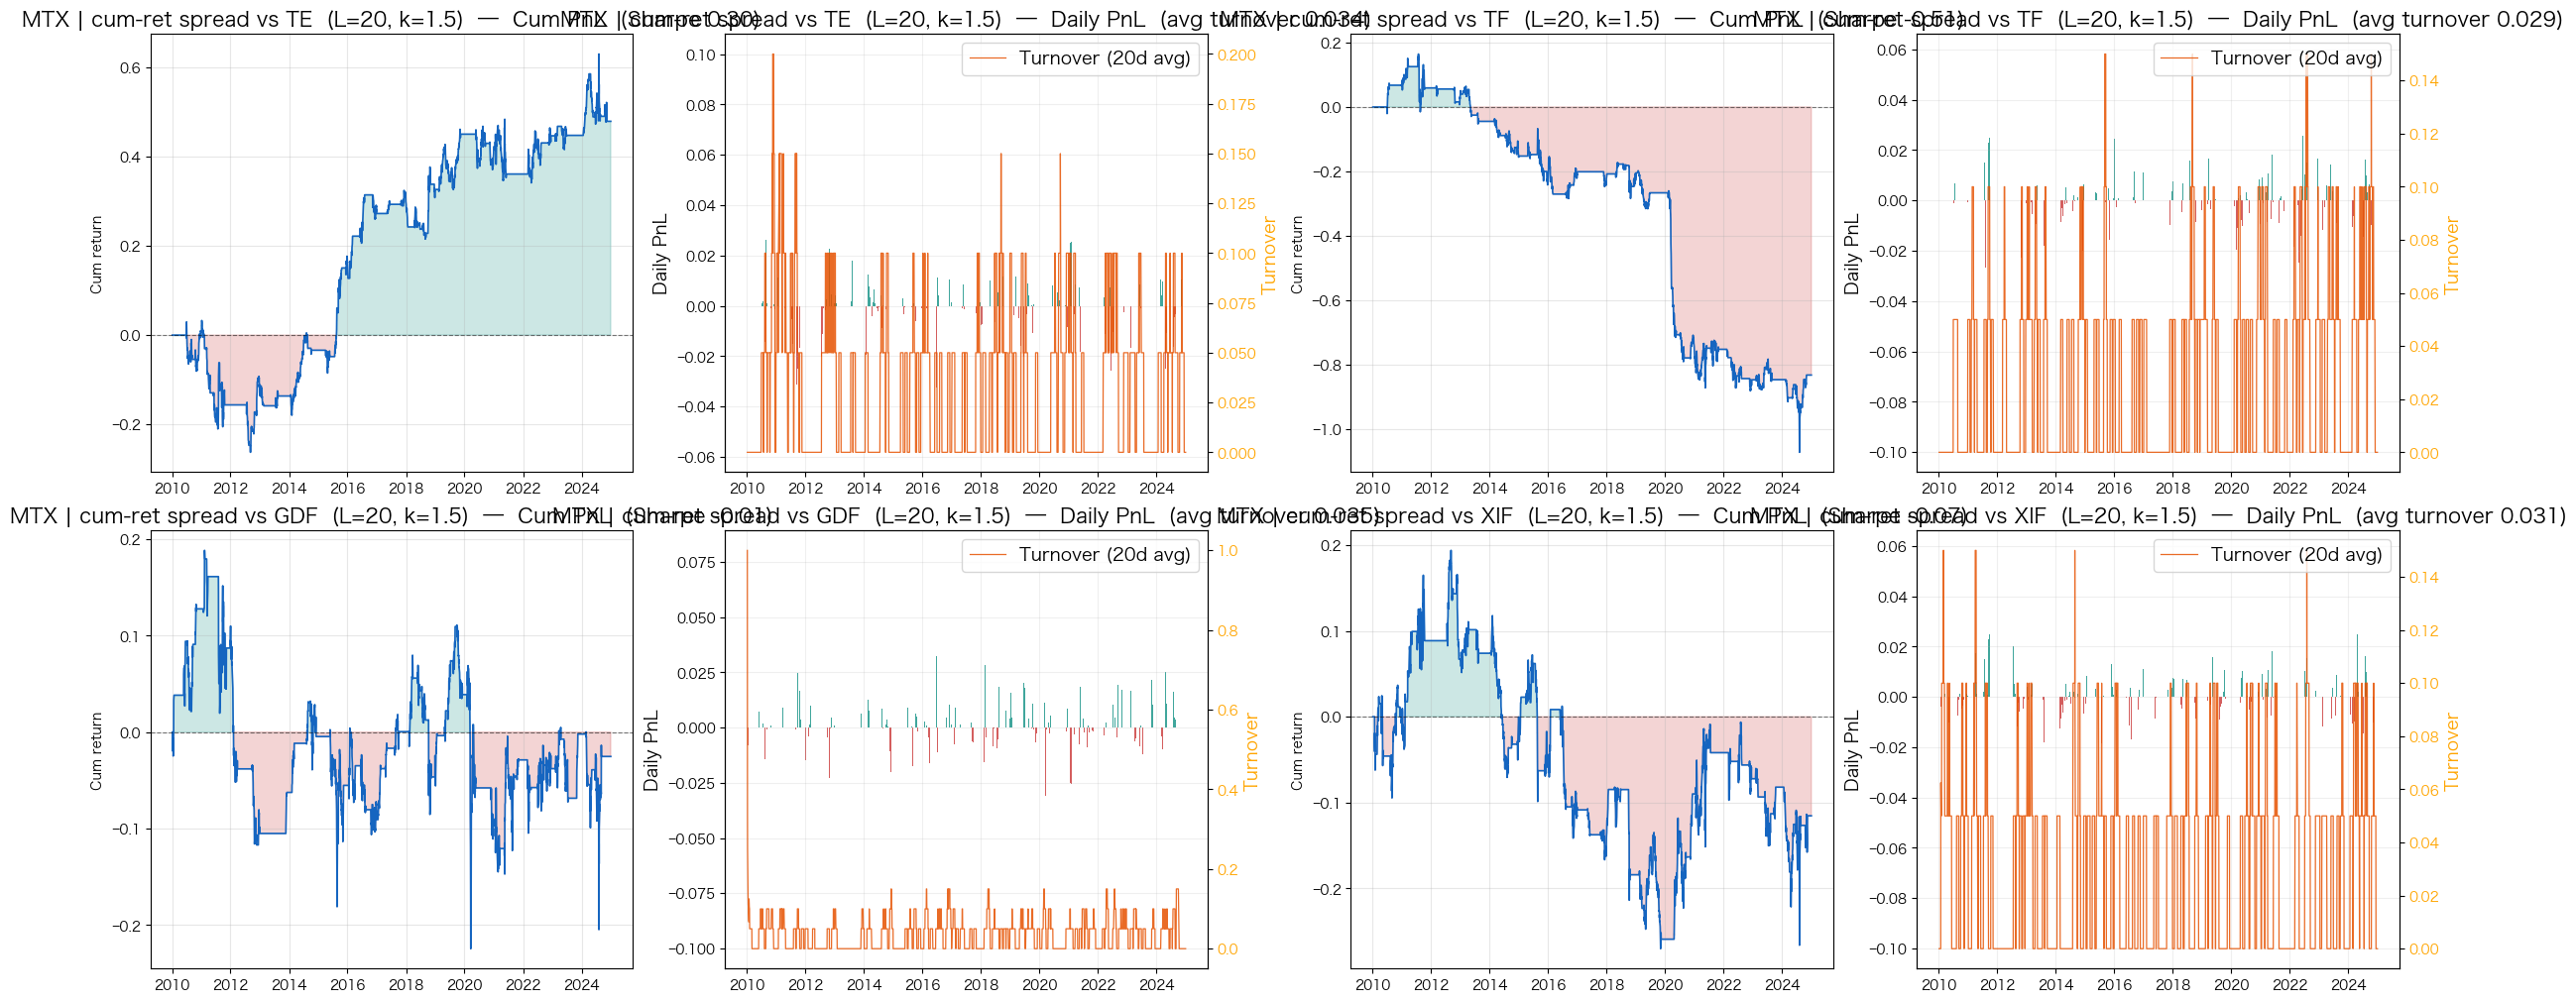

In [13]:
PARTNERS = ["TE", "TF", "GDF", "XIF"]
LOOKBACK   = 20
THRESHOLD  = 1.5

# Build signals — use the FULL-history return series so the rolling stats
# get a real warmup. SimulateAll/Simulate will slice to the global eval
# window (2010-01-01 → 2024-12-31) automatically.
sigs_cumret, names_cumret = [], []
for code in PARTNERS:
    sig = cum_ret_spread_signal(
        assets["MTX"].returns, assets[code].returns,
        lookback=LOOKBACK, std_window=252, threshold=THRESHOLD,
        hold_until_revert=True,
    )
    sigs_cumret.append(sig)
    names_cumret.append(f"MTX | cum-ret spread vs {code}  (L={LOOKBACK}, k={THRESHOLD})")

# normalize=False so the signal is taken as-is (it's already in {-1, 0, +1})
cta.SimulateAll(*sigs_cumret, names=names_cumret, normalize=False)

### Lookback sweep on the best pair

Fix the partner at TE (the only ADF-cointegrated pair besides TX) and sweep
the cumulative-return lookback. Faster lookbacks react sooner but pick up
more noise; slower lookbacks may smooth out the trade signal entirely.

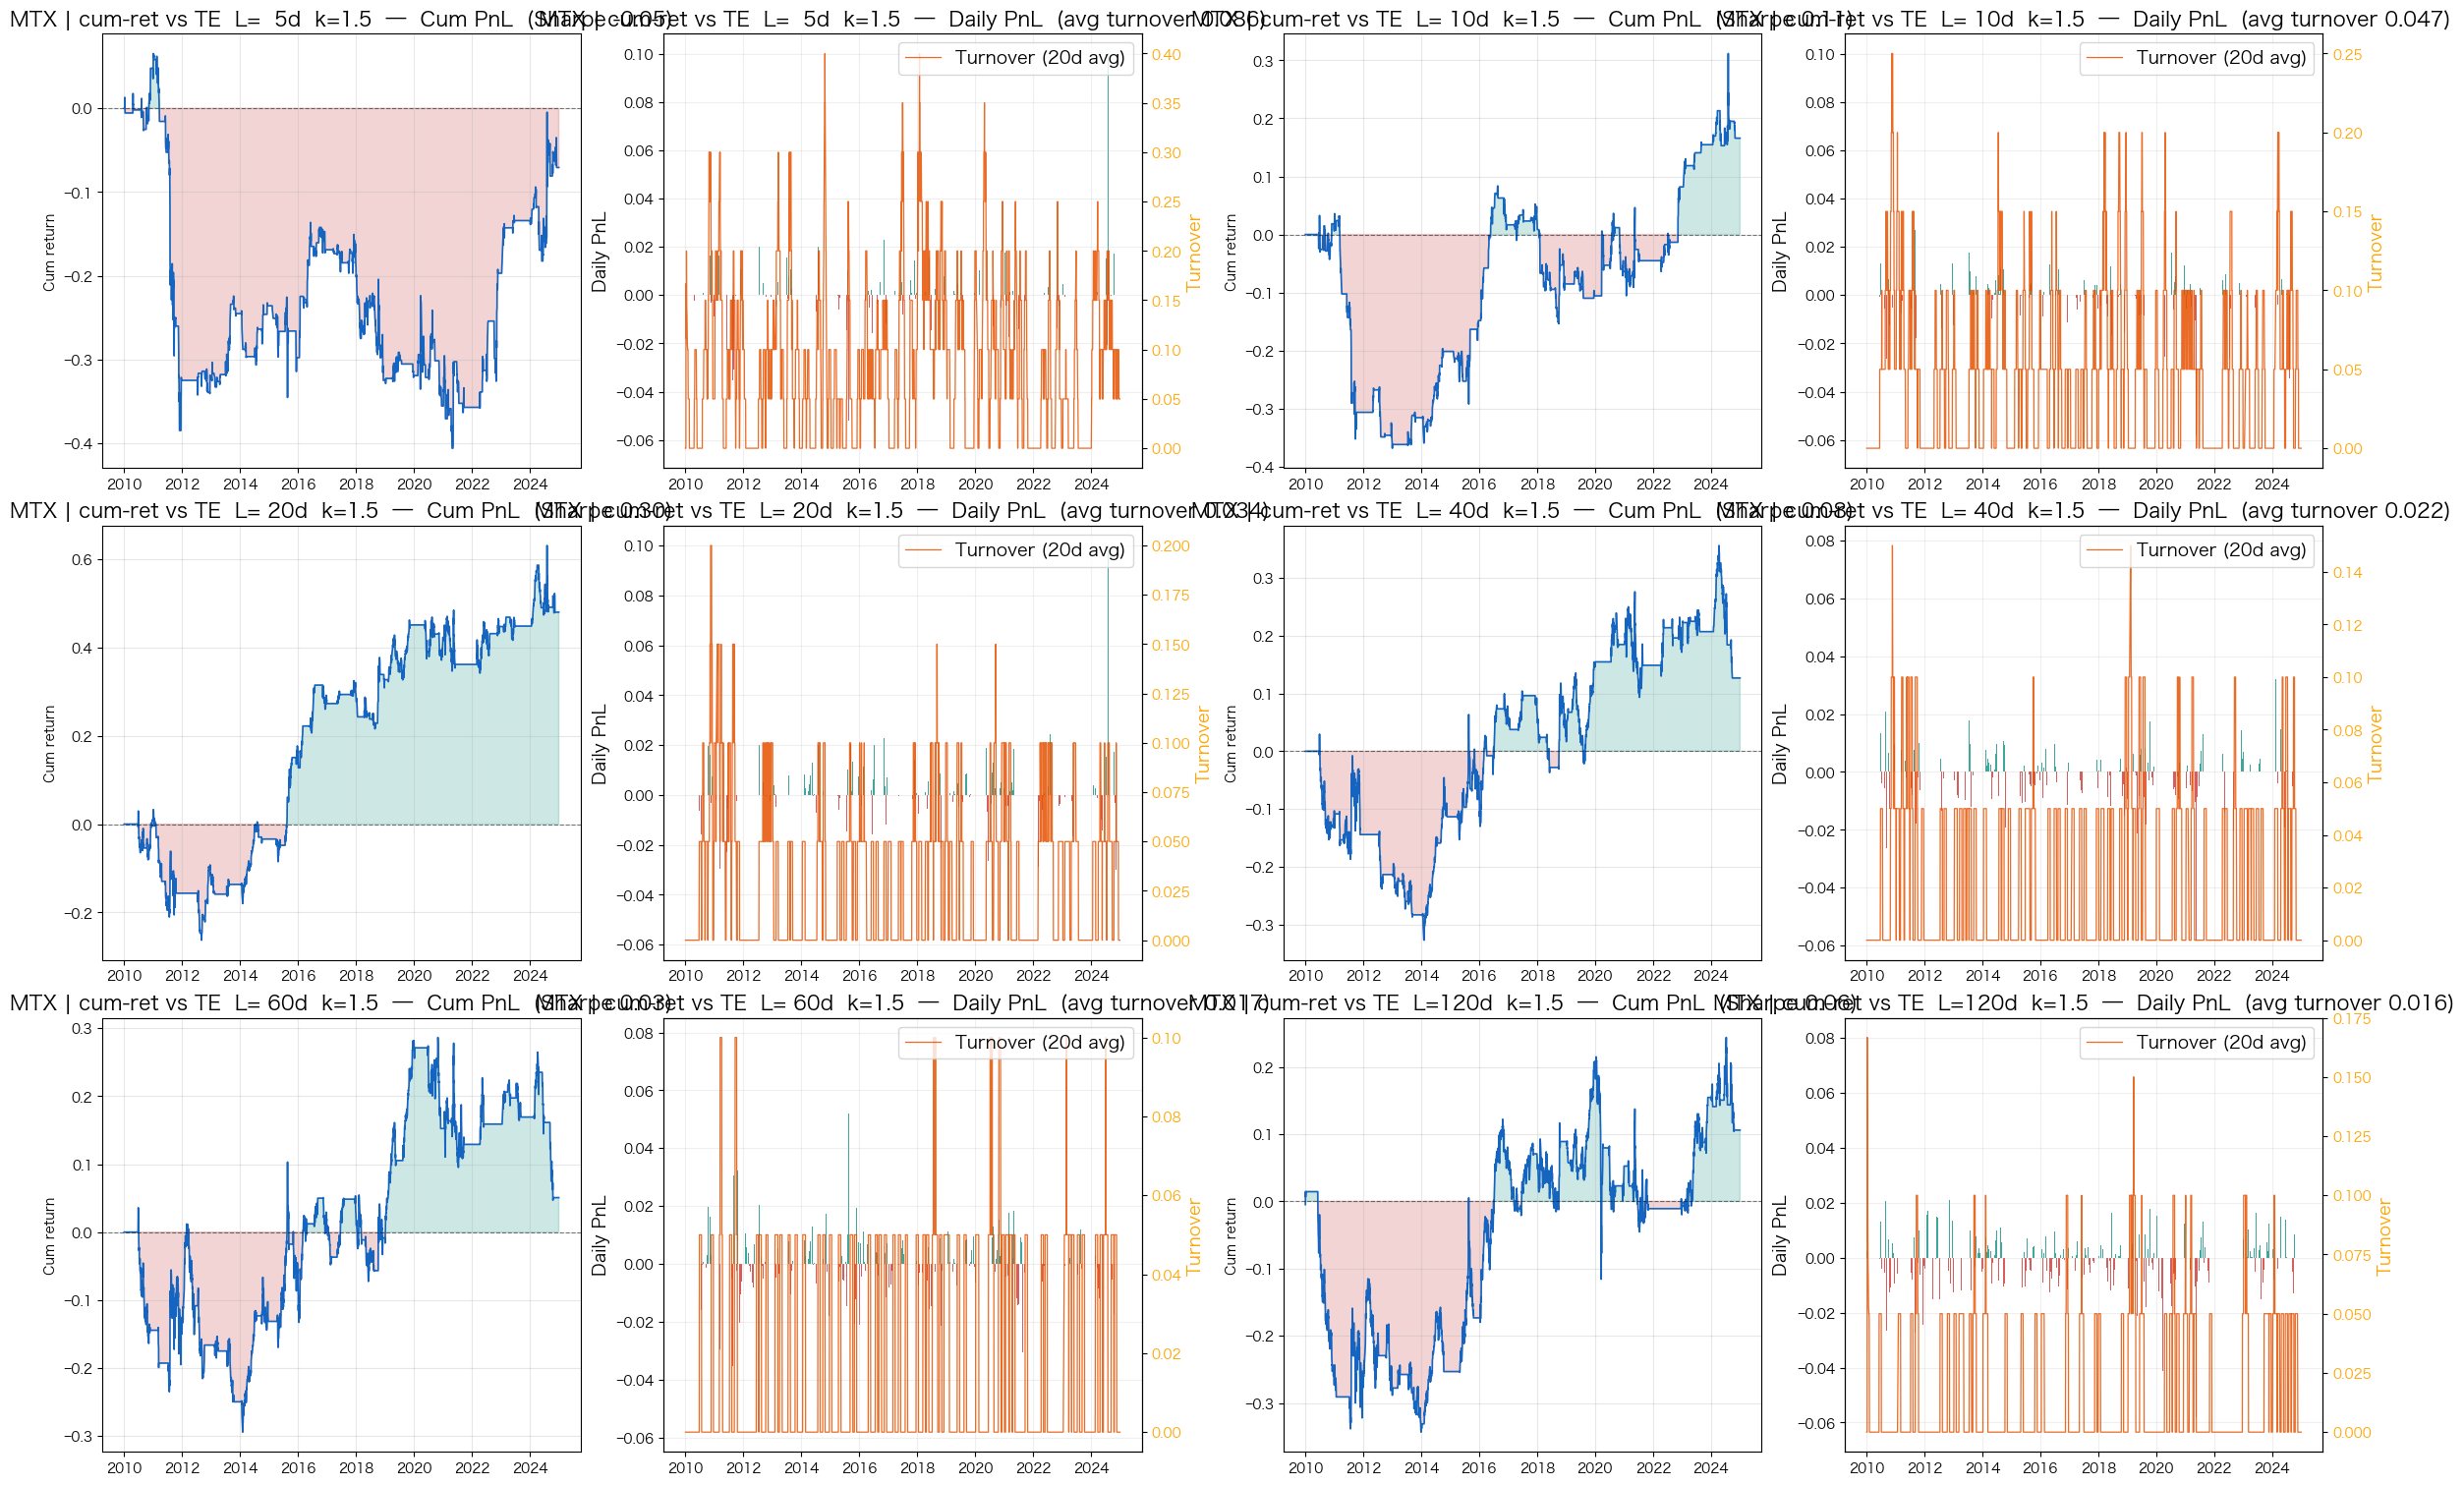

In [14]:
PARTNER = "TE"
LOOKBACKS_TO_TRY = [5, 10, 20, 40, 60, 120]

sigs_L, names_L = [], []
for L in LOOKBACKS_TO_TRY:
    sig = cum_ret_spread_signal(
        assets["MTX"].returns, assets[PARTNER].returns,
        lookback=L, std_window=252, threshold=THRESHOLD,
        hold_until_revert=True,
    )
    sigs_L.append(sig)
    names_L.append(f"MTX | cum-ret vs {PARTNER}  L={L:>3}d  k={THRESHOLD}")

cta.SimulateAll(*sigs_L, names=names_L, normalize=False)

### B. Log-price-difference spread (cointegration style)

Same four partners, but the spread is now `log(MTX) − β·log(other)` with β
estimated by 252-day rolling OLS. This is the "textbook" pairs-trade spread —
when the hedge ratio is stable, this is more powerful than the cum-ret
version because it directly tracks price-level dislocations rather than
return drifts.

For pairs where the hedge ratio drifts (TF, GDF, XIF — based on the
rolling-β plot earlier), expect this version to do worse than for TE.

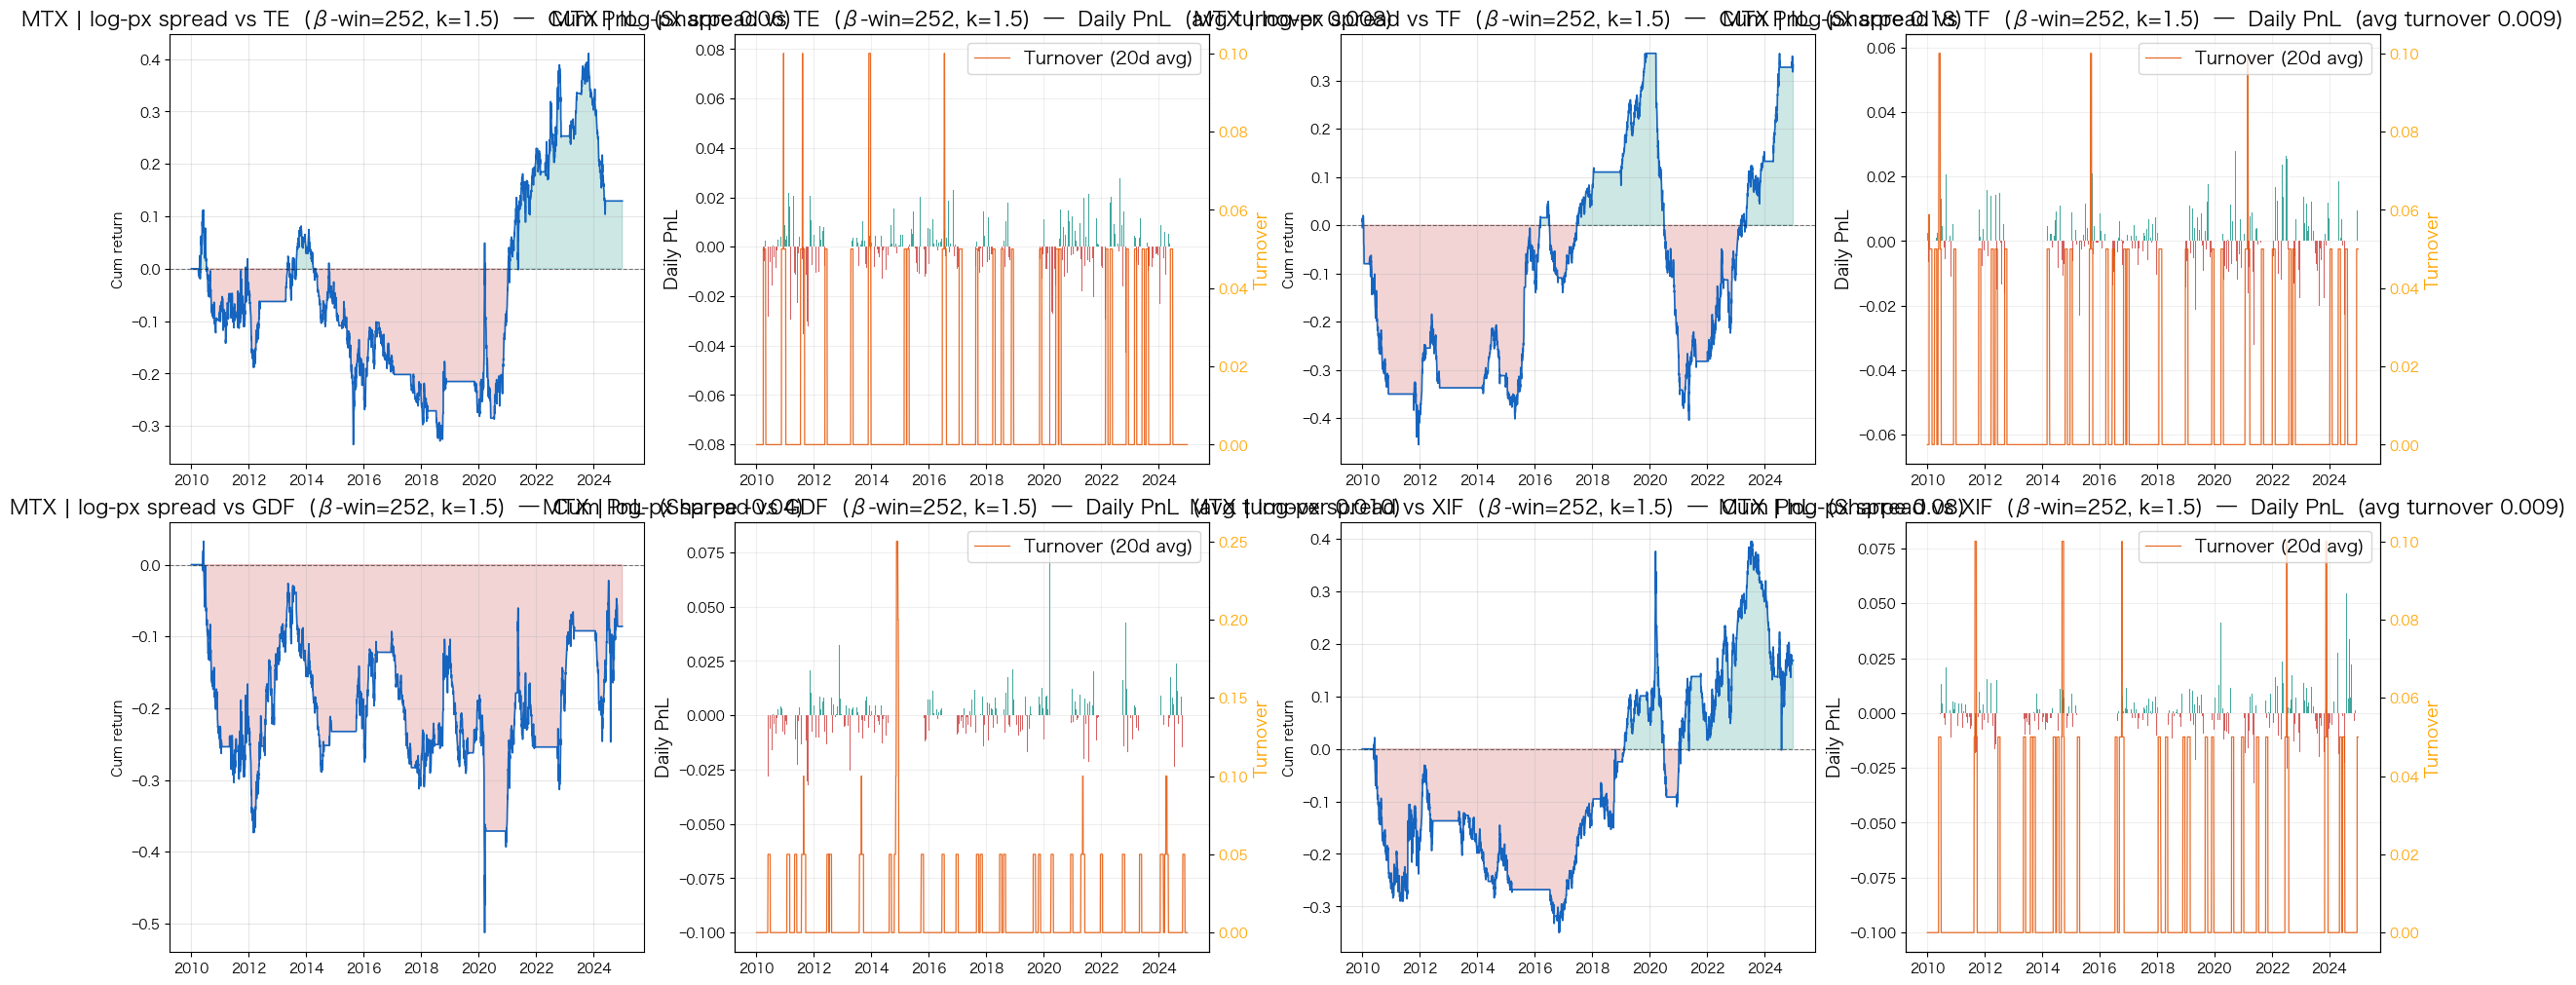

In [15]:
sigs_logpx, names_logpx = [], []
for code in PARTNERS:
    sig = log_price_spread_signal(
        assets["MTX"].close, assets[code].close,
        beta_window=252, std_window=252, threshold=THRESHOLD,
        hold_until_revert=True,
    )
    sigs_logpx.append(sig)
    names_logpx.append(f"MTX | log-px spread vs {code}  (β-win=252, k={THRESHOLD})")

cta.SimulateAll(*sigs_logpx, names=names_logpx, normalize=False)

### Head-to-head on TE — cum-ret vs log-price

Direct comparison of the two signal definitions on the strongest pair, using
the same threshold. Whichever wins in-sample tells you which "spread"
representation captures the actual mean-reversion edge.

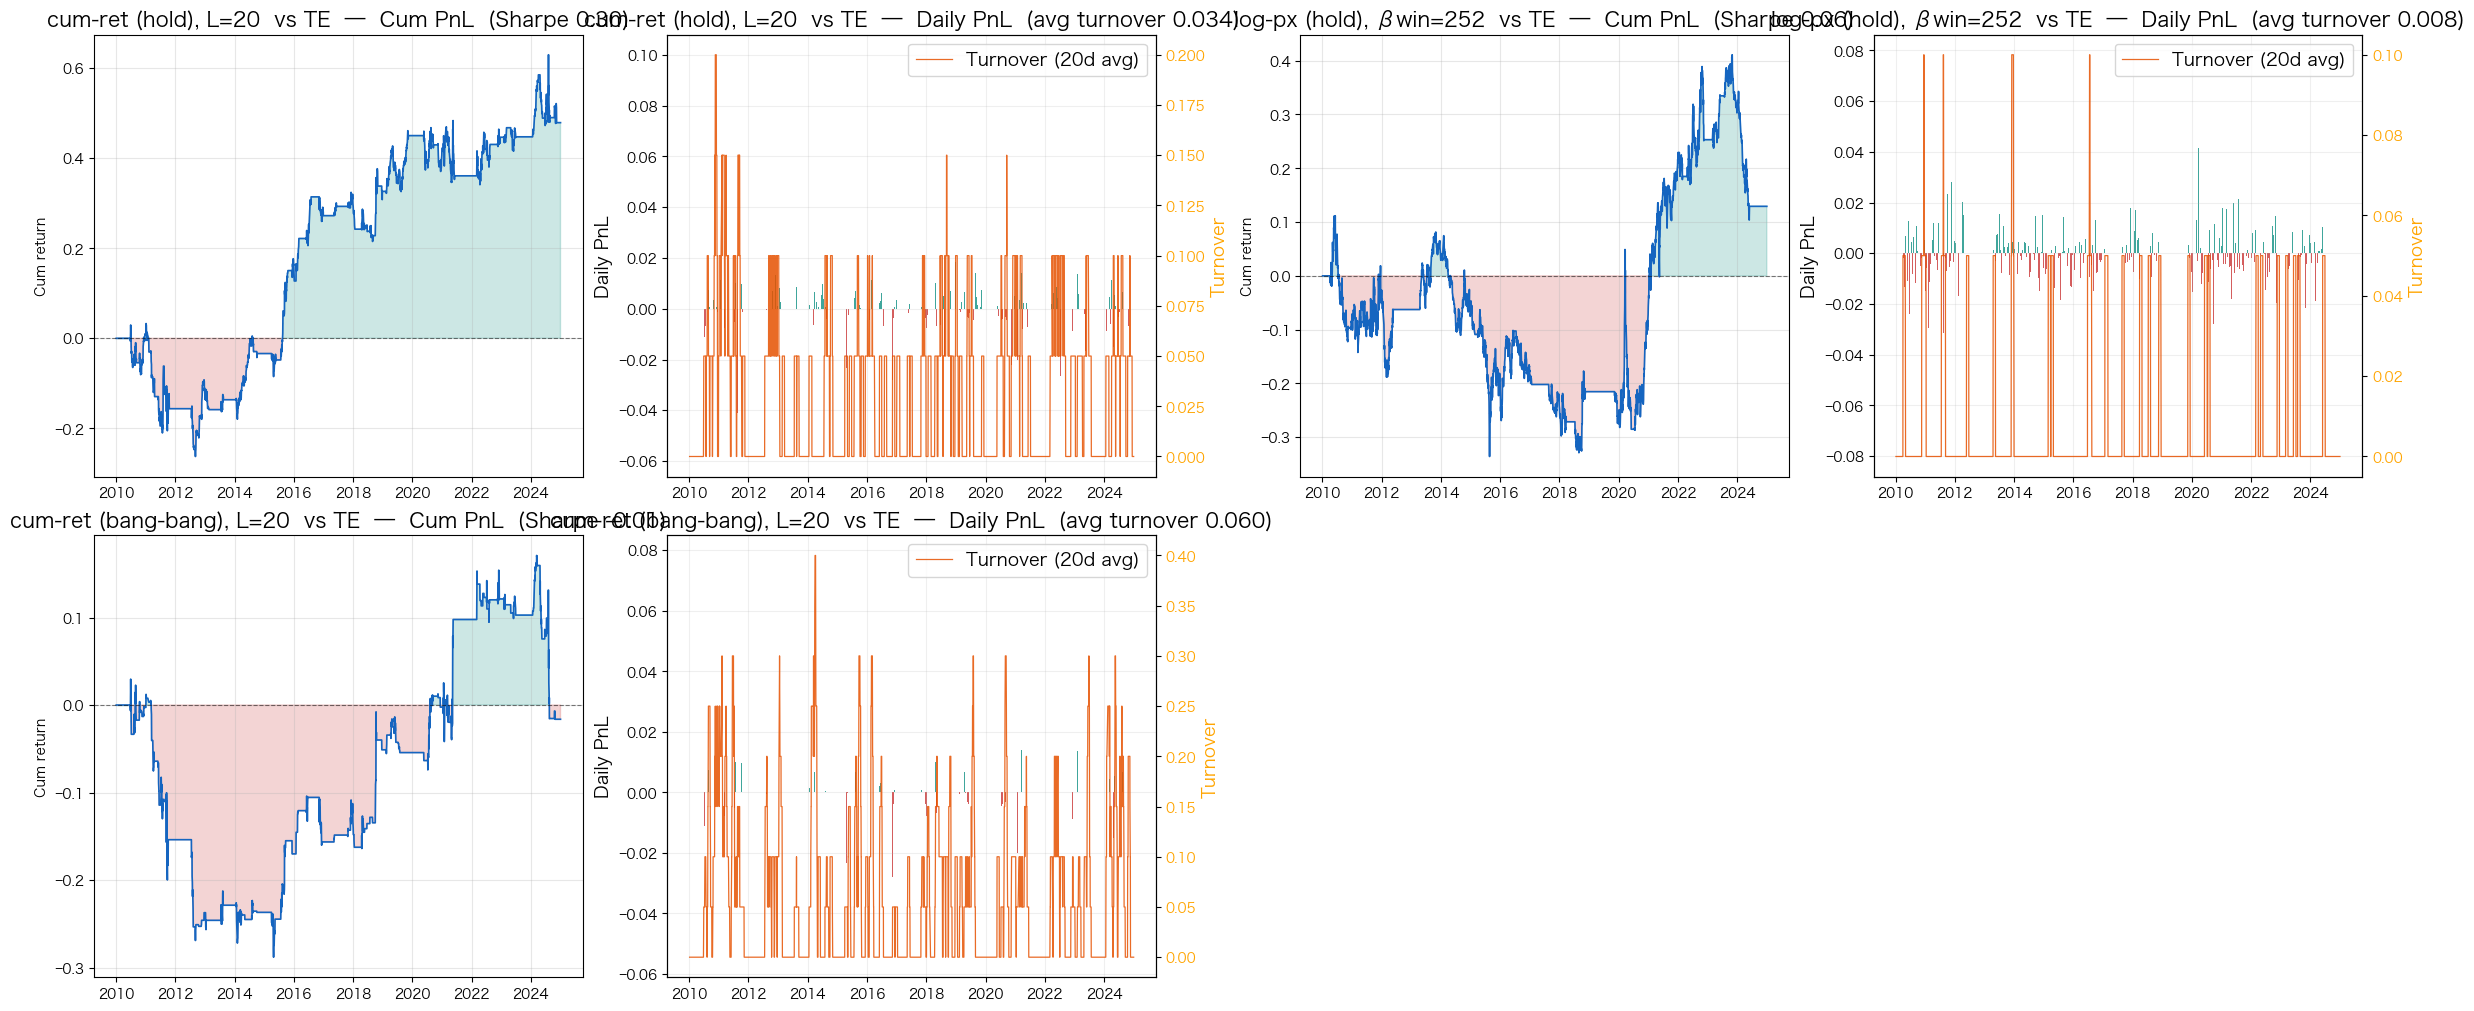

In [16]:
sig_cum  = cum_ret_spread_signal(
    assets["MTX"].returns, assets[PARTNER].returns,
    lookback=20, std_window=252, threshold=THRESHOLD, hold_until_revert=True,
)
sig_log  = log_price_spread_signal(
    assets["MTX"].close, assets[PARTNER].close,
    beta_window=252, std_window=252, threshold=THRESHOLD, hold_until_revert=True,
)
sig_bang = cum_ret_spread_signal(
    assets["MTX"].returns, assets[PARTNER].returns,
    lookback=20, std_window=252, threshold=THRESHOLD, hold_until_revert=False,
)

cta.SimulateAll(
    sig_cum, sig_log, sig_bang,
    names=[
        f"cum-ret (hold), L=20  vs {PARTNER}",
        f"log-px (hold), βwin=252  vs {PARTNER}",
        f"cum-ret (bang-bang), L=20  vs {PARTNER}",
    ],
    normalize=False,
)